In [213]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate



def setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Legend ---
    plt.rcParams.update({
        "legend.fontsize": fontsize,      # Match your fontsize
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 1.0,
        "legend.edgecolor": "black",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)


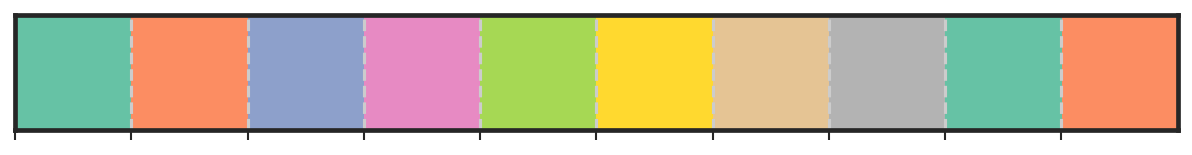

In [214]:
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [215]:
df = pd.read_csv("Liverpool10k2026.csv")
df

,First Name,Last Name,Gender,Club,Time
0,Joshua,Garcia,Male,NaN,00:42:24.00
1,William,Young,Male,NaN,00:51:18.00
2,Renee,Daniel,Female,NaN,00:41:29.00
3,Timothy,Barnes,Male,NaN,00:52:25.00
4,Juan,Hensley,Male,North Endurance,00:42:51.00
...,...,...,...,...,...
193,Larry,Owens,Male,NaN,00:41:06.00
194,Pamela,Oliver,Female,NaN,01:10:05.00
195,Jacob,Martin,Male,Dockside Runners,00:46:38.00
196,Kerry,Smith,Female,NaN,01:04:21.00


In [216]:
times = df["Time"].values
times = times.to_numpy()
# conversion of time from string to seconds
for i, t in enumerate(times):
    h, m, s = t.split(":")
    try:
        times[i] = int(h) * 60*60 + int(m) * 60 + float(s)

    except ValueError:
        print(f"Error converting time: {t}, {h}, {m}, {s}")
        print(f'index:{i}')
    

Error converting time: O0:56:06.00, O0, 56, 06.00
index:156


In [217]:
times[156] = 56*60 + 6.0


In [218]:
df['Time']=times


In [219]:
for t in times:
    if isinstance(t, str):
        print(f"Error: time value is still a string: {t}")
    if np.isnan(t):
        print(f"Error: time value is NaN: {t}")

In [220]:
def GEV (x, mu, sig, xi):
    #if xi == 0:
        #return print("xi cannot be zero")
    x = np.asarray(x, dtype=float)
    factor = 1/sig *(1 + xi *(x-mu)/sig)**(-1/xi-1)
    exponent = -(1 + xi *(x-mu)/sig)**(-1/xi)
    
    return factor * np.exp(exponent)

def ln_likelihood(vals, func, mu, sig, xi):
    pdf_vals = func(vals, mu, sig, xi)
    
    return -np.sum(np.log(pdf_vals))

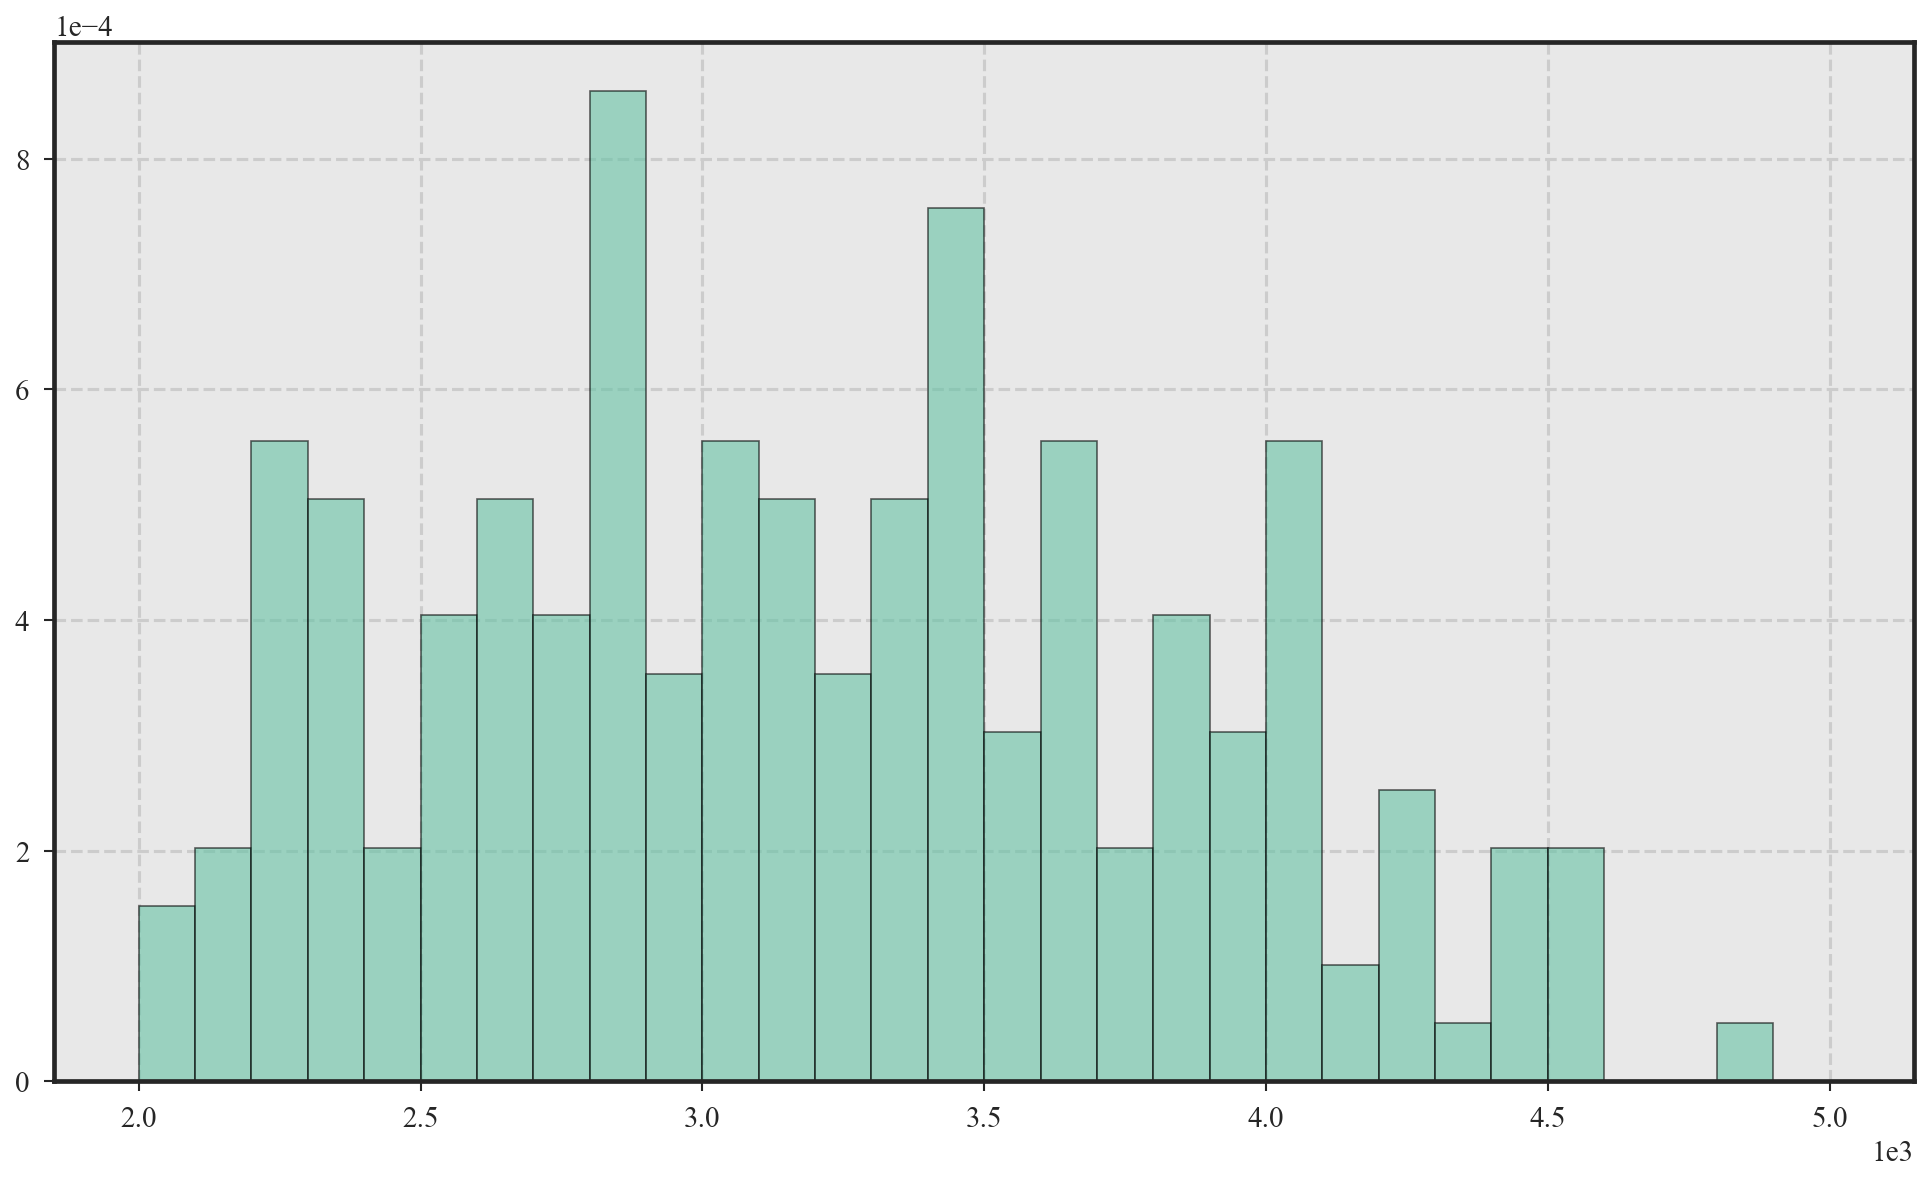

In [221]:
Nbins= 30

xrange = (2000, 5000)
counts, edges = np.histogram(df['Time'], bins=Nbins, range=xrange, density=True)

plt.hist(df['Time'], bins=Nbins, range=xrange, density=True, alpha=0.6, color=colors[0], edgecolor='black');

In [222]:
m = Minuit(lambda mu,sig,xi: ln_likelihood(times, GEV, mu, sig, xi), mu=np.mean(times), sig=np.std(times), xi=0.5)
#m.limits['xi'] = (0.001, None)  # xi > 0.001, effectively non-zero
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1560                       │              Nfcn = 179              │
│ EDM = 4.75e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu   │  2.96e3   │  0.07e3   │            │            │         │         │       │
│ 1 │ sig  │    610    │    50     │            │            │         │         │       │
│ 2 │ xi   │   -0.22   │   0.08    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬────────────────────────────┐
│     │       mu      sig       xi │
├─────┼────────────────────────────┤
│  mu │ 4.94e+03    0.6e3   -2.587 │
│ sig │    0.6e3 2.66e+03   -2.554 │
│  xi │   -2.587   -2.554  0.00712 │
└─────┴────────────────────────────┘

In [223]:
ln_like_vals = ln_likelihood(times, GEV, m.values['mu'], m.values['sig'], m.values['xi'])
print(f"Log-likelihood at best fit: {ln_like_vals}")
print(f"Best fit parameters: mu={m.values['mu']}, sig={m.values['sig']}, xi={m.values['xi']}")
print(f"Best fit parameters (with uncertainties): mu={m.values['mu']} ± {m.errors['mu']}, sig={m.values['sig']} ± {m.errors['sig']}, xi={m.values['xi']} ± {m.errors['xi']}")

Log-likelihood at best fit: 1560.04057561835
Best fit parameters: mu=2960.4407975222734, sig=613.7130894034722, xi=-0.2220114994828259
Best fit parameters (with uncertainties): mu=2960.4407975222734 ± 70.29272032975149, sig=613.7130894034722 ± 51.53291445964345, xi=-0.2220114994828259 ± 0.0843763482239527


In [224]:
ullhfit = cost.UnbinnedNLL(times, GEV)
mfit_ullh = Minuit(ullhfit, mu = np.mean(times), sig=np.std(times), xi =0.5)
#mfit_ullh.limits['xi'] = (0.001, None) or (None, -0.001)  # xi > 0.001, effectively non-zero
mfit_ullh.migrad()           # Perform the actual fit

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3120                       │              Nfcn = 179              │
│ EDM = 9.5e-06 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu   │  2.96e3   │  0.05e3   │            │            │         │         │       │
│ 1 │ sig  │    610    │    40     │            │            │         │         │       │
│ 2 │ xi   │   -0.22   │   0.06    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬────────────────────────────┐
│     │       mu      sig       xi │
├─────┼────────────────────────────┤
│  mu │ 2.47e+03    0.3e3   -1.294 │
│ sig │    0.3e3 1.33e+03   -1.277 │
│  xi │   -1.294   -1.277  0.00356 │
└─────┴────────────────────────────┘

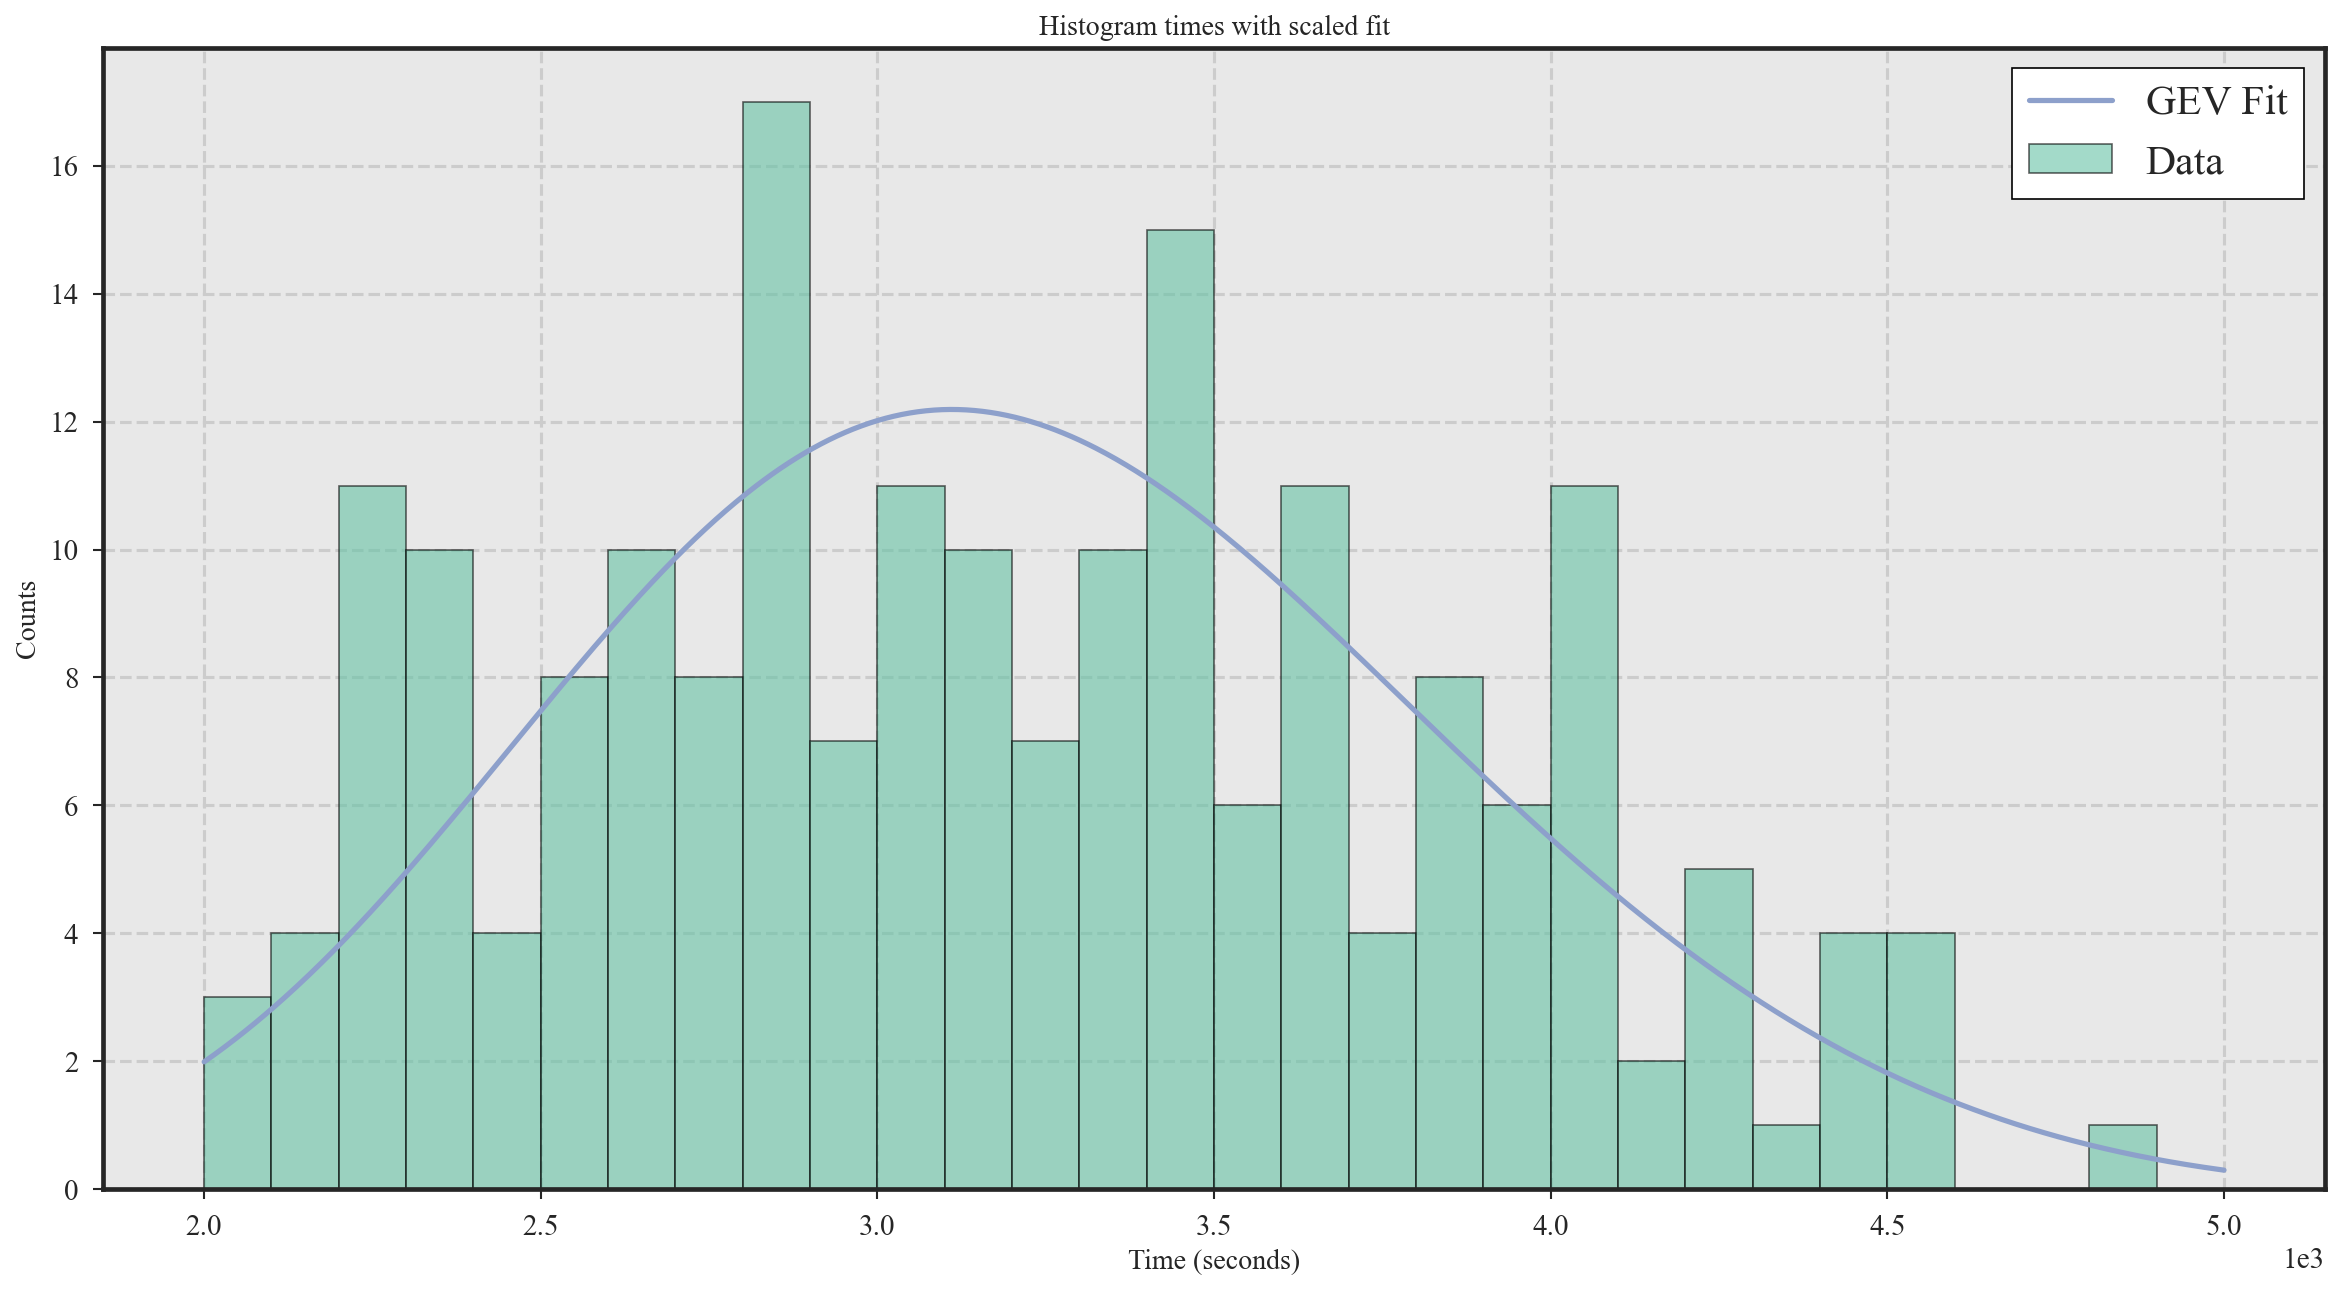

In [225]:
Nbins= 30

xrange = (2000, 5000)
x_axis = np.linspace(xrange[0], xrange[1], 1000)
counts, edges = np.histogram(df['Time'], bins=Nbins, range=xrange, density=False)
bin_width = edges[1] - edges[0]
scale = bin_width * counts.sum() 

plt.plot(x_axis, scale * GEV(x_axis, m.values['mu'],
                              m.values['sig'],
                              m.values['xi']),
                              label='GEV Fit',
                              color=colors[2],
                              linewidth=2.5)

plt.hist(df['Time'], bins=Nbins, range=xrange, density=False, alpha=0.6, color=colors[0], edgecolor='black', label='Data');
plt.xlabel("Time (seconds)")
plt.ylabel("Counts")
plt.title("Histogram times with scaled fit")
plt.legend()
plt.tight_layout()
plt.show()

In [226]:
name = 'Tanyusha'
result = df[df['First Name'] == name]
tanyusha_time = result['Time'].values[0]
print(f"Tanyusha's time: {tanyusha_time} seconds")

fraction_slower = 1 - integrate.quad(lambda x: GEV(x, m.values['mu'], m.values['sig'], m.values['xi']), 0, tanyusha_time)[0]
print(f"Fraction of runners with times slower than Tanyusha's: {fraction_slower:.4f}")
e_fraction_slower = np.sqrt(fraction_slower * (1 - fraction_slower) / len(times))
print(f"Estimated uncertainty on fraction: {e_fraction_slower:.4f}")

fraction_slower_emp = np.sum(times > tanyusha_time)/len(times)
print(f"Fraction of runners with times slower than Tanyusha's (empirical): {fraction_slower_emp:.4f}")
e_fraction_slower_emp = np.sqrt(fraction_slower_emp * (1 - fraction_slower_emp) / len(times))
print(f"Estimated uncertainty on fraction (empirical): {e_fraction_slower_emp:.4f}")

sigs = (fraction_slower_emp - fraction_slower) / np.sqrt(e_fraction_slower**2 + e_fraction_slower_emp**2)
print(f"Significance of difference: {sigs:.4f} sigma")

Tanyusha's time: 3747.0 seconds
Fraction of runners with times slower than Tanyusha's: 0.1985
Estimated uncertainty on fraction: 0.0283
Fraction of runners with times slower than Tanyusha's (empirical): 0.2273
Estimated uncertainty on fraction (empirical): 0.0298
Significance of difference: 0.6989 sigma


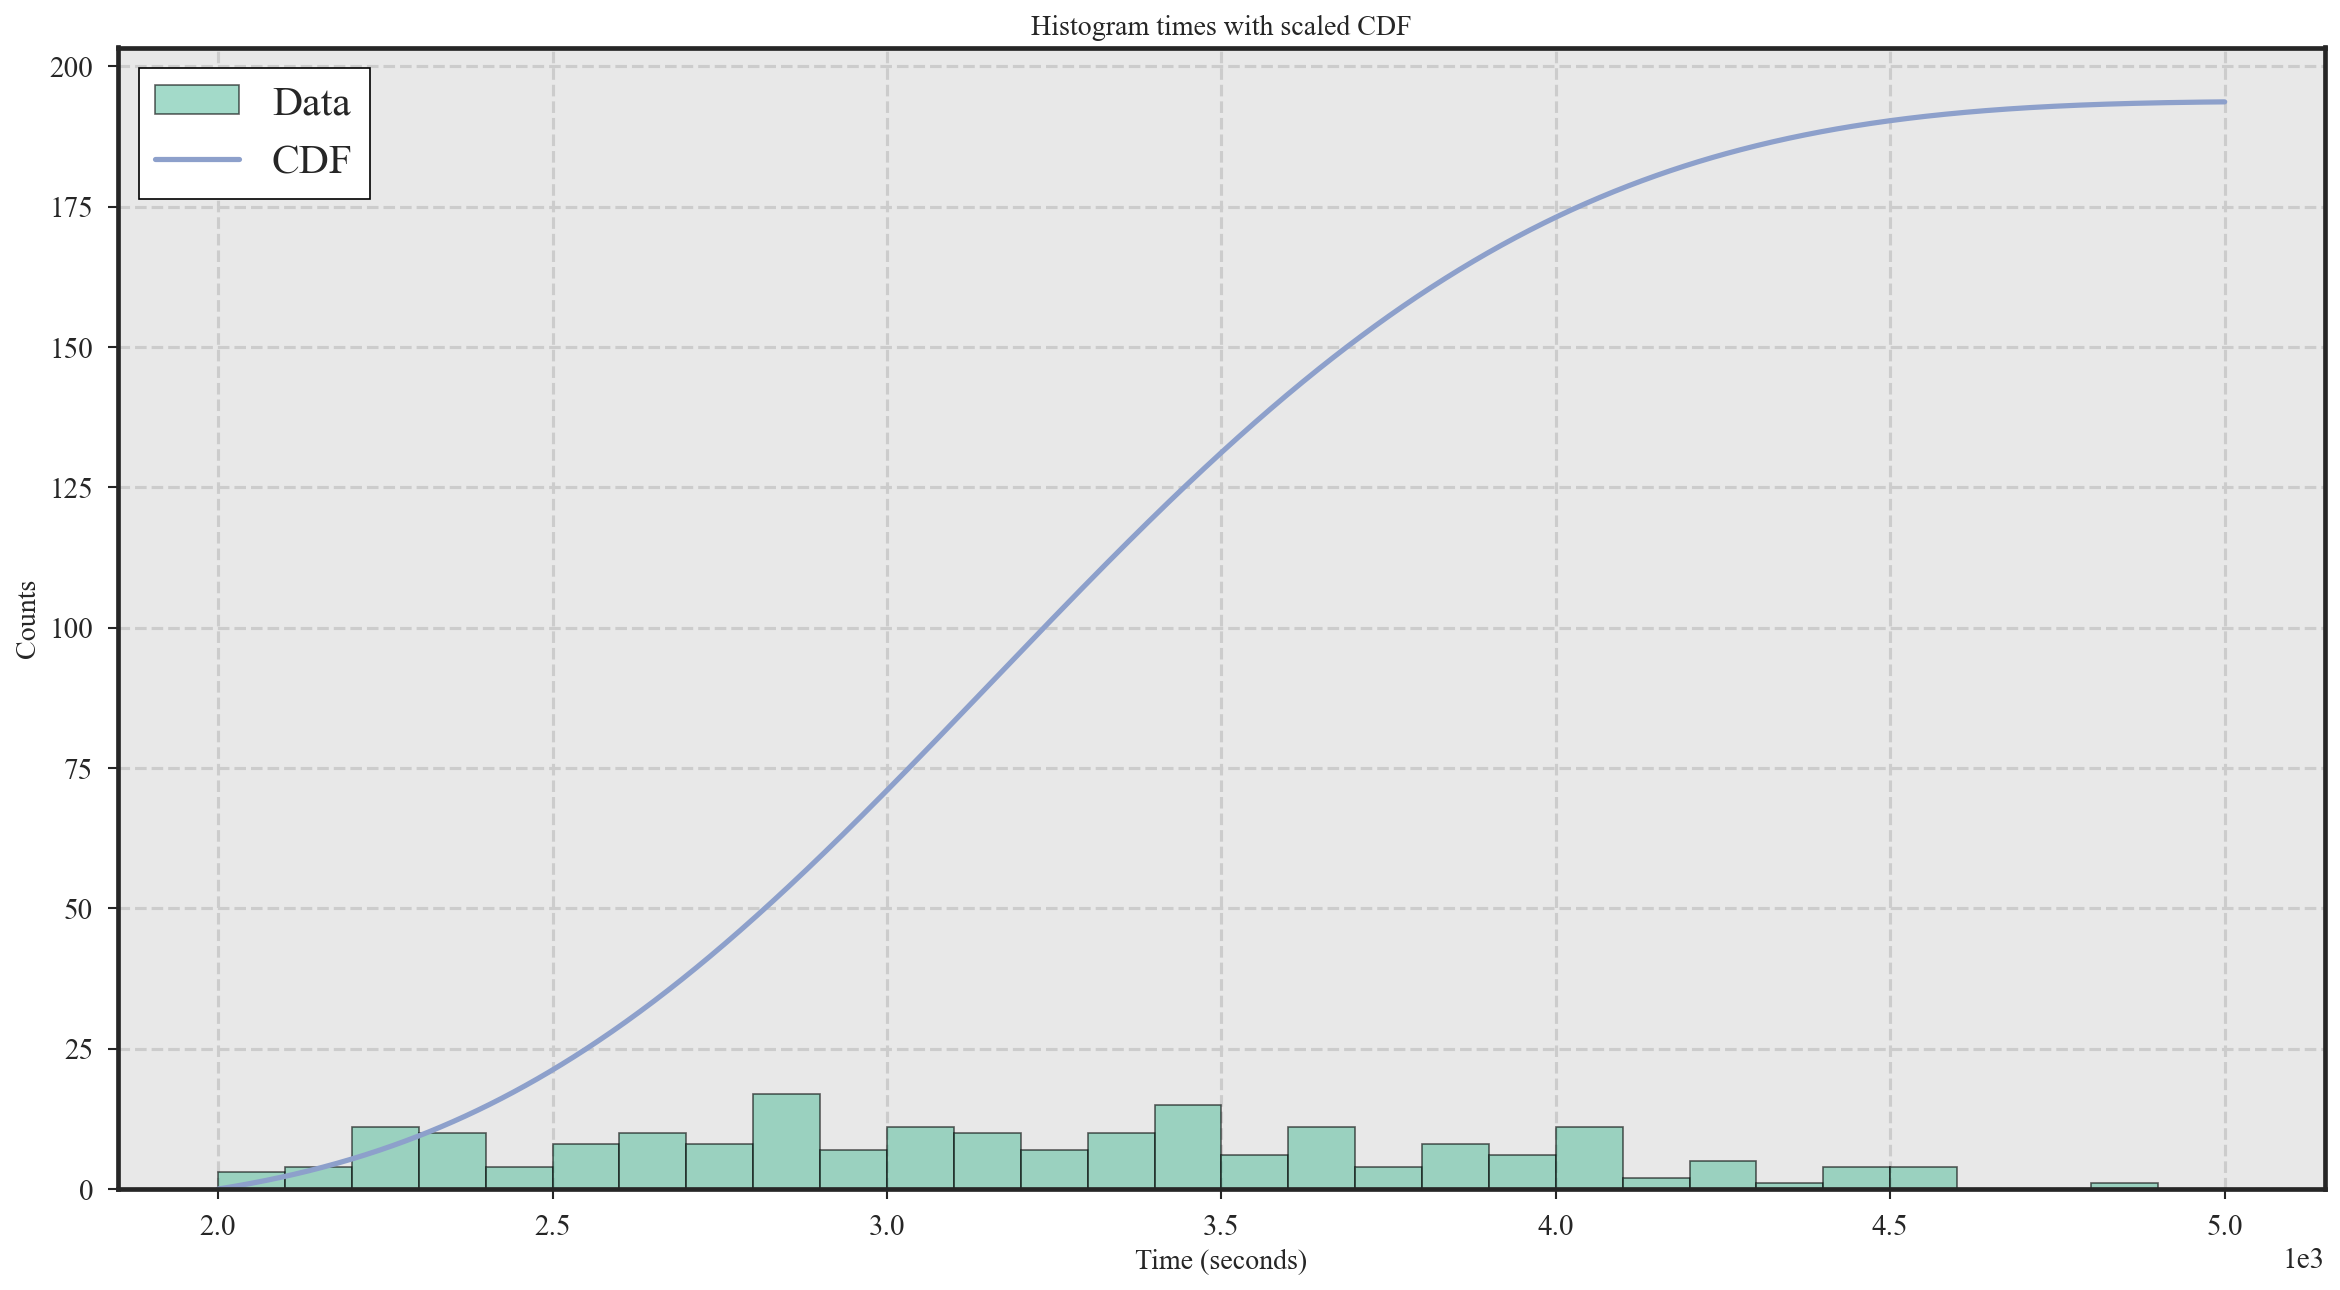

In [227]:
x_axis = np.linspace(xrange[0], xrange[1], 1000)
pdf_vals = GEV(x_axis, 2980, 607.5,-0.26)
cdf_vals = np.array([integrate.quad(lambda x: GEV(x, 2980, 607.5,-0.26), xrange[0], x)[0] for x in x_axis])
total_count = len(times)
scaled_cdf = cdf_vals * total_count
plt.hist(df['Time'], bins=Nbins, range=xrange, density=False, alpha=0.6, color=colors[0], edgecolor='black', label='Data');
plt.plot(x_axis, scaled_cdf, label='CDF', color=colors[2], linewidth=2.5)
plt.xlabel("Time (seconds)")
plt.ylabel("Counts")
plt.title("Histogram times with scaled CDF")
plt.legend()
plt.tight_layout()
plt.show()

In [228]:
p_of_fastest_time =integrate.quad(lambda x: GEV(x, 2980, 607.5,-0.26), xrange[0], np.min(df['Time']))[0]
print(f"Probability of observing a time as fast as the fastest runner: {p_of_fastest_time:.4e}")

Probability of observing a time as fast as the fastest runner: 4.8065e-04
